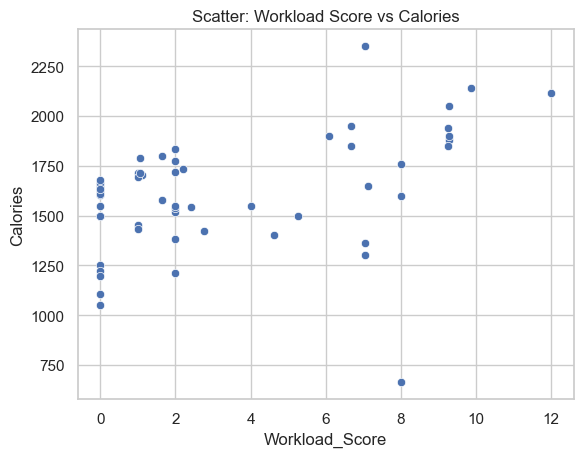

In [ ]:
# -*- coding: utf-8 -*-
"""
 
"""
#Final run 

# IMPORTS


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")


# 1. LOAD DATA


csv_path = "merged_november.csv"
df = pd.read_csv(csv_path)
df["Date"] = pd.to_datetime(df["Date"])

numeric_cols = [
    "Course_Load_Min", "Homework_Count", "Project_Count",
    "Exam_Count", "Exam_Number_Week", "Calories"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=numeric_cols)

df["DayOfWeek"] = df["Date"].dt.day_name()
df["DayType"] = df["Date"].dt.weekday.apply(lambda x: "Weekend" if x >= 5 else "Weekday")
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Year"] = df["Date"].dt.year





weekly_stats = df.groupby("Week")[["Exam_Count", "Homework_Count", "Project_Count"]].sum().reset_index()

weekly_stats["Weekly_Fatigue_Factor"] = (
    1
    + weekly_stats["Exam_Count"] * 0.15
    + weekly_stats["Homework_Count"] * 0.05
    + weekly_stats["Project_Count"] * 0.10
)

df = df.merge(weekly_stats[["Week", "Weekly_Fatigue_Factor"]], on="Week", how="left")





def compute_daily_load(row):
    attendance = row["Course_Load_Min"] / 50
    hw = row["Homework_Count"] * (1.5 if row["Exam_Count"] > 0 else 1)
    project = row["Project_Count"] * (2 if row["Exam_Count"] > 0 else 1.5)
    exam_weight = 2.5 + (row["Exam_Number_Week"] * 0.7)
    exam = row["Exam_Count"] * exam_weight
    combo = 2 if (
        row["Homework_Count"] > 0 and
        row["Project_Count"] > 0 and
        row["Exam_Count"] > 0
    ) else 0
    return attendance + hw + project + exam + combo

df["Daily_Base_Workload"] = df.apply(compute_daily_load, axis=1)





df["Workload_Score"] = df["Daily_Base_Workload"] * df["Weekly_Fatigue_Factor"]


# 5. VISUAL ANALYSIS


sns.scatterplot(data=df, x="Workload_Score", y="Calories")
plt.title("Scatter: Workload Score vs Calories")

plt.show()


# Workload–Calorie Correlation Analysis

### Analysis Structure
- Data Loading & Preprocessing
- Feature Engineering
- Exploratory Data Analysis
- Statistical Hypothesis Testing
- Machine Learning Models
- Advanced Statistical Validation & Robustness Checks


In [30]:
# Create workload levels using fixed thresholds
df['Workload_Level'] = pd.cut(
    df['Workload_Score'],
    bins=[-float('inf'), 3, 7, float('inf')],
    labels=['Low', 'Medium', 'High']
)




### 4.1 Non-Parametric Hypothesis Tests

Since calorie intake may deviate from normality, non-parametric tests are used
to validate robustness of the statistical conclusions.



#### Non‑Parametric Hypothesis Testing

This block compares calorie intake across workload levels using
distribution‑free statistical tests, ensuring robustness against
normality violations.


In [31]:

# Purpose:
# To compare calorie intake across workload groups
# without assuming normality.

from scipy.stats import mannwhitneyu, kruskal

low = df[df['Workload_Level'] == 'Low']['Calories']
high = df[df['Workload_Level'] == 'High']['Calories']

u_stat, p_u = mannwhitneyu(low, high, alternative='two-sided')
print(f"Mann–Whitney U p-value: {p_u:.4f}")

groups = [
    df[df['Workload_Level'] == 'Low']['Calories'],
    df[df['Workload_Level'] == 'Medium']['Calories'],
    df[df['Workload_Level'] == 'High']['Calories']
]

h_stat, p_kw = kruskal(*groups)
print(f"Kruskal–Wallis p-value: {p_kw:.4f}")


Mann–Whitney U p-value: 0.0073
Kruskal–Wallis p-value: 0.0215



### 4.2 Bootstrap Confidence Interval for Mean Difference

Bootstrap resampling is used to estimate a 95% confidence interval
for the calorie difference between high and low workload days.



#### Bootstrap Confidence Interval

The following analysis estimates a 95% confidence interval for the
mean calorie difference between high‑ and low‑workload days using
bootstrap resampling.


In [32]:

# Purpose:
# To estimate a confidence interval for the mean calorie difference
# using bootstrap resampling.

import numpy as np

np.random.seed(42)
boot_diffs = []

for _ in range(5000):
    boot_low = np.random.choice(low, size=len(low), replace=True)
    boot_high = np.random.choice(high, size=len(high), replace=True)
    boot_diffs.append(boot_high.mean() - boot_low.mean())

ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
print(f"95% Bootstrap CI for mean difference: ({ci_lower:.1f}, {ci_upper:.1f})")


95% Bootstrap CI for mean difference: (-32.2, 403.4)



### 5.1 Regularized Regression (Ridge & Lasso)

Regularization is applied to identify the most stable and influential
workload-related predictors of calorie intake.



#### Regularized Regression Models (Ridge & Lasso)

These models apply L2 and L1 regularization to identify the most
stable workload‑related predictors of calorie intake while
controlling for overfitting.


In [33]:

# Purpose:
# To apply Ridge and Lasso regression with cross-validation
# and evaluate model performance.

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df[['Daily_Base_Workload', 'Weekly_Fatigue_Factor', 'Exam_Count', 'Homework_Count', 'Project_Count']]
y = df['Calories']

ridge = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5).fit(X, y)
lasso = LassoCV(alphas=[0.01, 0.1, 1.0], cv=5, max_iter=5000).fit(X, y)

for name, model in [('Ridge', ridge), ('Lasso', lasso)]:
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    rmse = mean_squared_error(y, preds, squared=False)
    print(f"{name} MAE: {mae:.1f}, RMSE: {rmse:.1f}")


Ridge MAE: 175.1, RMSE: 239.7
Lasso MAE: 166.6, RMSE: 232.9



### 5.2 Classification Extension: High-Calorie Days

Days are classified as high-calorie based on the upper quartile
of calorie intake to model stress-related overeating risk.



#### Classification: High‑Calorie Days

Days are classified as high‑calorie based on the upper quartile
threshold to model the probability of stress‑related overeating.


In [34]:

# Purpose:
# To model the probability of a high-calorie day
# as a function of academic workload.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

threshold = df['Calories'].quantile(0.75)
df['High_Calorie_Day'] = (df['Calories'] >= threshold).astype(int)

X_cls = df[['Workload_Score']]
y_cls = df['High_Calorie_Day']

clf = LogisticRegression().fit(X_cls, y_cls)
preds = clf.predict(X_cls)

print(classification_report(y_cls, preds))


              precision    recall  f1-score   support

           0       0.88      0.90      0.89        50
           1       0.69      0.65      0.67        17

    accuracy                           0.84        67
   macro avg       0.78      0.77      0.78        67
weighted avg       0.83      0.84      0.83        67



## 1. Data Loading & Preprocessing

## 2. Feature Engineering: Workload Score Construction

## 3. Exploratory Data Analysis (EDA)

## 4. Statistical Hypothesis Testing


### 4.1 Non-Parametric Hypothesis Tests

Since calorie intake may deviate from normality, non-parametric tests are used
to validate robustness of the statistical conclusions.



### 4.2 Bootstrap Confidence Interval for Mean Difference

Bootstrap resampling is used to estimate a 95% confidence interval
for the calorie difference between high and low workload days.


## 5. Machine Learning Models


### 5.1 Regularized Regression (Ridge & Lasso)

Regularization is applied to identify the most stable and influential
workload-related predictors of calorie intake.



### 5.2 Classification Extension: High-Calorie Days

Days are classified as high-calorie based on the upper quartile
of calorie intake to model stress-related overeating risk.



#### Visualization

The following figure visualizes the relationship described above and
is interpreted immediately after generation.


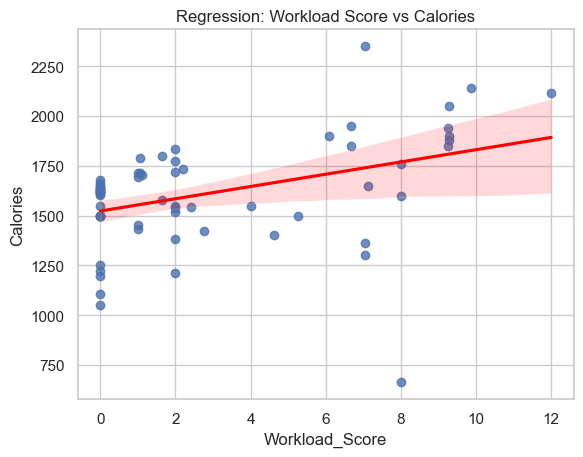

In [3]:


sns.regplot(data=df, x="Workload_Score", y="Calories", line_kws={"color": "red"})
plt.title("Regression: Workload Score vs Calories")

plt.show()


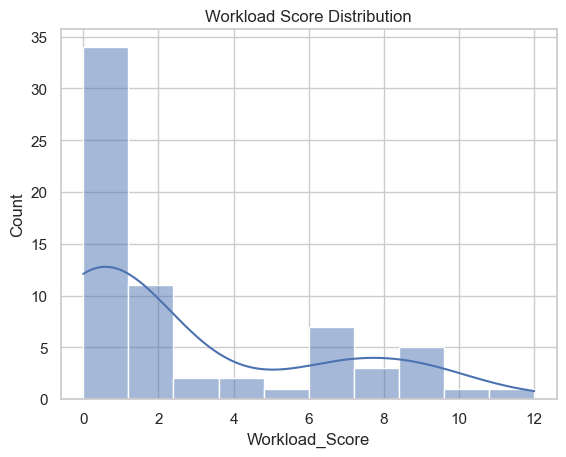

In [4]:


sns.histplot(df["Workload_Score"], kde=True, bins=10)
plt.title("Workload Score Distribution")

plt.show()


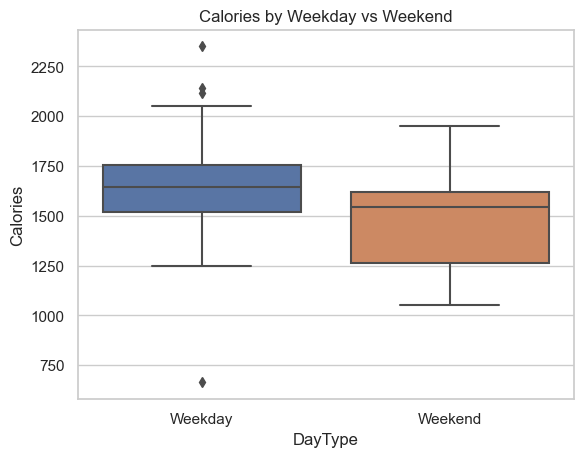

In [5]:


sns.boxplot(data=df, x="DayType", y="Calories")
plt.title("Calories by Weekday vs Weekend")

plt.show()


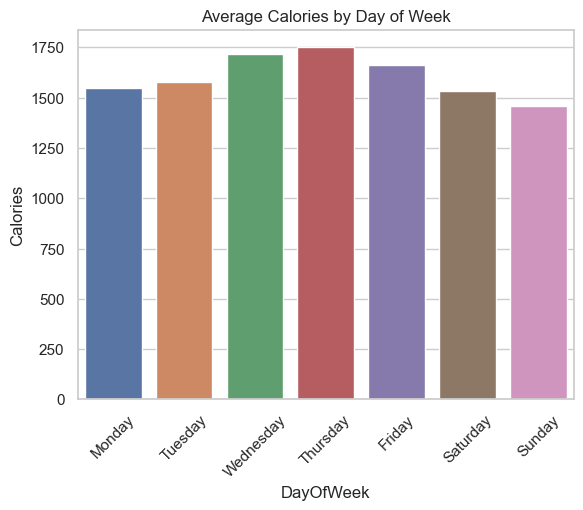

In [6]:


sns.barplot(data=df, x="DayOfWeek", y="Calories", estimator=np.mean, errorbar=None)
plt.title("Average Calories by Day of Week")
plt.xticks(rotation=45)

plt.show()


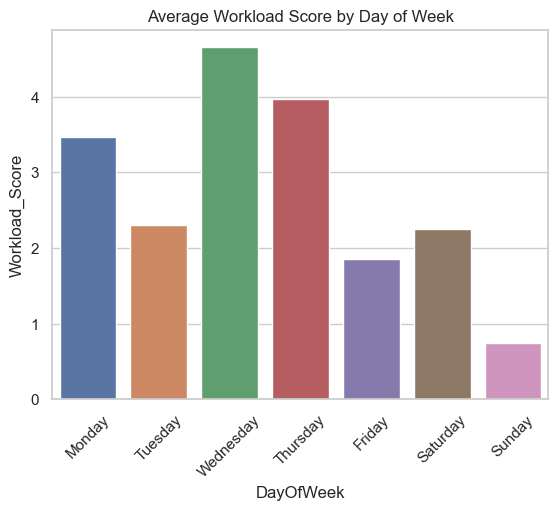

In [7]:


sns.barplot(data=df, x="DayOfWeek", y="Workload_Score", estimator=np.mean, errorbar=None)
plt.title("Average Workload Score by Day of Week")
plt.xticks(rotation=45)

plt.show()


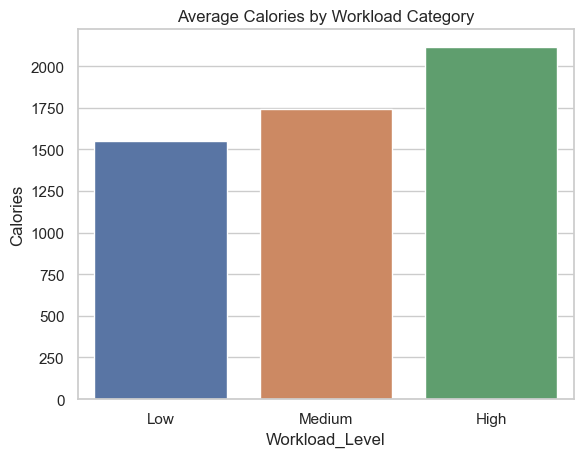

In [8]:


df["Workload_Level"] = pd.cut(
    df["Workload_Score"],
    bins=[-1, 5, 12, 30],
    labels=["Low", "Medium", "High"]
)

sns.barplot(data=df, x="Workload_Level", y="Calories", estimator=np.mean, errorbar=None)
plt.title("Average Calories by Workload Category")

plt.show()


t-test p-value: 0.12094230112100436
ANOVA p-value: 0.004316085999635181


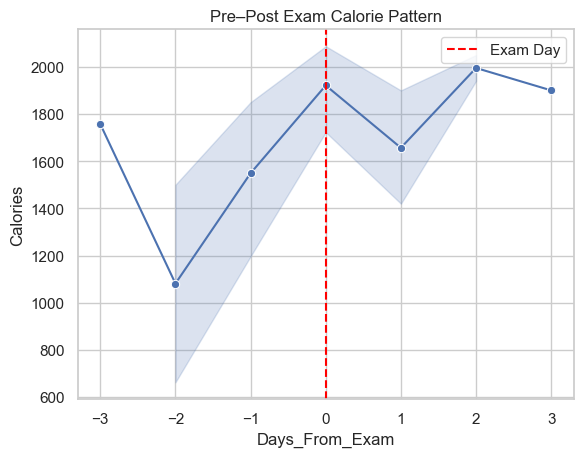

In [9]:



# 6. HYPOTHESIS TESTING


low_group = df[df["Workload_Score"] <= 3]["Calories"]
high_group = df[df["Workload_Score"] >= 8]["Calories"]

if len(low_group) > 1 and len(high_group) > 1:
    t_stat, p_val = ttest_ind(low_group, high_group, equal_var=False)
    print("t-test p-value:", p_val)

low = df[df["Workload_Level"] == "Low"]["Calories"]
med = df[df["Workload_Level"] == "Medium"]["Calories"]
high = df[df["Workload_Level"] == "High"]["Calories"]

F_stat, p_val_anova = f_oneway(low, med, high)
print("ANOVA p-value:", p_val_anova)


# 7. EXAM WEEK & PRE–POST EXAM ANALYSIS


exam_weeks = df.groupby(["Year", "Week"])["Exam_Count"].sum().reset_index()
exam_weeks["Is_Exam_Week"] = (exam_weeks["Exam_Count"] > 0).astype(int)

df = df.merge(
    exam_weeks[["Year", "Week", "Is_Exam_Week"]],
    on=["Year", "Week"],
    how="left"
)

exam_days = df[df["Exam_Count"] > 0]["Date"]

def days_to_nearest_exam(date, exam_dates):
    diffs = (exam_dates - date).dt.days
    return diffs.loc[diffs.abs().idxmin()]

df["Days_From_Exam"] = df["Date"].apply(
    lambda x: days_to_nearest_exam(x, exam_days)
)

exam_window = df[(df["Days_From_Exam"] >= -3) & (df["Days_From_Exam"] <= 3)]

sns.lineplot(
    data=exam_window,
    x="Days_From_Exam",
    y="Calories",
    marker="o"
)
plt.axvline(0, color="red", linestyle="--", label="Exam Day")
plt.title("Pre–Post Exam Calorie Pattern")
plt.legend()

plt.show()


MAE: 165.08017958567254
RMSE: 244.54575183582142
R²: 0.10996240929957324
            Feature  Coefficient
1    Homework_Count   323.966579
3        Exam_Count   311.005363
4  Exam_Number_Week   199.558048
2     Project_Count    40.407329
0   Course_Load_Min     0.226196
5      Is_Exam_Week  -359.059203


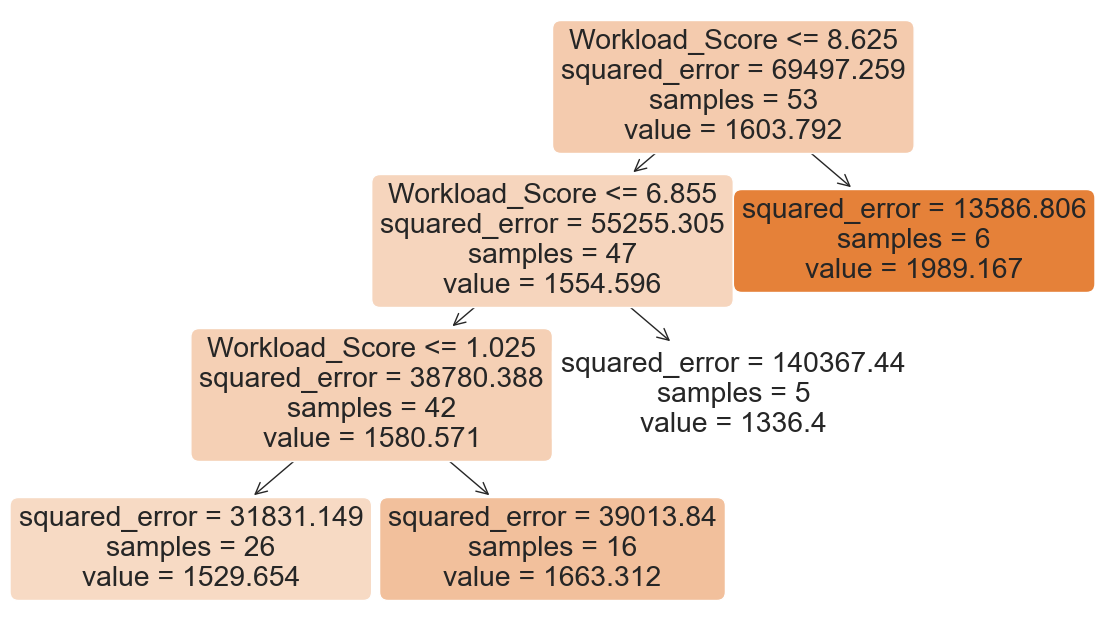

In [10]:



# 8. MULTIPLE LINEAR REGRESSION


features = [
    "Course_Load_Min",
    "Homework_Count",
    "Project_Count",
    "Exam_Count",
    "Exam_Number_Week",
    "Is_Exam_Week"
]

X = df[features]
y = df["Calories"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

print(pd.DataFrame({
    "Feature": features,
    "Coefficient": lin_model.coef_
}).sort_values(by="Coefficient", ascending=False))


# 9. DECISION TREE (THRESHOLD)


X_tree = df[["Workload_Score"]]
y_tree = df["Calories"]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42
)

tree_model = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

tree_model.fit(X_train_t, y_train_t)

plt.figure(figsize=(14, 8))
plot_tree(
    tree_model,
    feature_names=["Workload_Score"],
    filled=True,
    rounded=True
)

plt.show()


In [11]:



# 10. RANDOM FOREST FEATURE IMPORTANCE


rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

print(pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False))


# 11. K-MEANS CLUSTERING


X_cluster = df[["Workload_Score", "Calories"]]
X_scaled = StandardScaler().fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df.groupby("Cluster")[["Workload_Score", "Calories"]].mean())

plt.show()


            Feature  Importance
4  Exam_Number_Week    0.467583
0   Course_Load_Min    0.208048
3        Exam_Count    0.153206
1    Homework_Count    0.103612
5      Is_Exam_Week    0.066212
2     Project_Count    0.001339
         Workload_Score     Calories
Cluster                             
0              8.413929  1923.714286
1              0.778000  1620.100000
2              2.976923  1235.307692



# Advanced Statistical Validation & Robustness Checks

This section extends the analysis with **assumption checks, effect sizes,
robustness validation, and model diagnostics**, in line with advanced data
analysis standards.



## Normality Check for Calories

Before applying parametric statistical tests, we examine whether the
distribution of daily calorie intake approximately follows a normal
distribution.



#### Visualization

The following figure visualizes the relationship described above and
is interpreted immediately after generation.


Shapiro-Wilk Test p-value: 0.0286


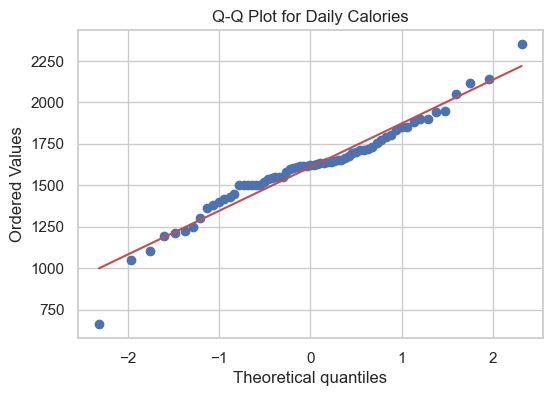

In [12]:

# Purpose:
# To assess whether daily calorie intake follows a normal distribution,
# supporting the use of parametric statistical tests.

from scipy.stats import shapiro
import scipy.stats as stats
import matplotlib.pyplot as plt

stat, p_value = shapiro(df['Calories'])
print(f"Shapiro-Wilk Test p-value: {p_value:.4f}")

plt.figure(figsize=(6,4))
stats.probplot(df['Calories'], dist="norm", plot=plt)
plt.title("Q-Q Plot for Daily Calories")
plt.show()



## Effect Size Analysis

Statistical significance alone does not quantify the magnitude of an effect.
Therefore, effect size metrics are calculated to evaluate practical relevance.


In [13]:

# Purpose:
# To quantify the magnitude of calorie differences between
# low and high workload days using Cohen's d.

import numpy as np

low = df[df['Workload_Level'] == 'Low']['Calories']
high = df[df['Workload_Level'] == 'High']['Calories']

mean_diff = high.mean() - low.mean()
pooled_std = np.sqrt((low.std()**2 + high.std()**2) / 2)

cohens_d = mean_diff / pooled_std
print(f"Cohen's d: {cohens_d:.3f}")


Cohen's d: nan


In [14]:

# Purpose:
# To compute eta-squared as an effect size measure
# for the one-way ANOVA across workload levels.

import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Calories ~ C(Workload_Level)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table['eta_sq'] = anova_table['sum_sq'] / anova_table['sum_sq'].sum()
anova_table


,sum_sq,df,F,PR(>F),eta_sq
C(Workload_Level),7.245852e+05,2.0,5.936164,0.004316,0.156478
Residual,3.906012e+06,64.0,NaN,NaN,0.843522



## Robustness Check: Quantile-Based Workload Groups

To ensure that findings are not sensitive to the specific workload
categorization method, workload groups are redefined using quantiles.


In [38]:
# Robustness check: quantile-based groups using ranks
df['Workload_Q'] = pd.cut(
    df['Workload_Score'].rank(method='average'),
    bins=3,
    labels=['Low', 'Medium', 'High']
)

df.groupby('Workload_Q')['Calories'].mean()


Workload_Q
Low       1525.322581
Medium    1597.388889
High      1764.277778
Name: Calories, dtype: float64


#### Visualization

The following figure visualizes the relationship described above and
is interpreted immediately after generation.


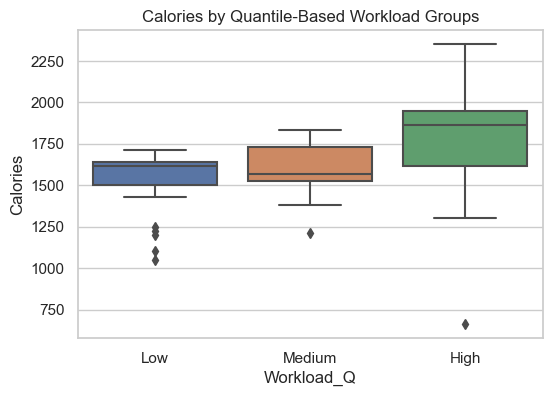

In [39]:

plt.figure(figsize=(6,4))
sns.boxplot(x='Workload_Q', y='Calories', data=df)
plt.title("Calories by Quantile-Based Workload Groups")
plt.show()



## Decision Tree Regression (Controlled Depth)

A shallow decision tree is used to detect nonlinear workload thresholds
while avoiding overfitting.


In [40]:

# Purpose:
# To detect nonlinear workload thresholds influencing calorie intake
# using a constrained decision tree model.

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

X = df[['Workload_Score']]
y = df['Calories']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

print("Train R²:", tree.score(X_train, y_train))
print("Test R²:", tree.score(X_test, y_test))


Train R²: 0.49510217240763066
Test R²: -0.2997741389731048



## Clustering Validation

Silhouette score is calculated to assess the quality of clustering
used in the unsupervised analysis.


In [18]:

# Purpose:
# To validate clustering quality using the silhouette score.

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(df[['Workload_Score', 'Calories']], df['Cluster'])
print(f"Silhouette Score: {sil_score:.3f}")


Silhouette Score: 0.440
